<a href="https://colab.research.google.com/github/Visweash1234/Applied-Data-Science-1/blob/main/ADS1_Tutorial_4_2_Basic_Statistics_and_Statistical_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # note this new package! used a lot in online examples
import pandas as pd

In [5]:
df_tesco = pd.read_csv('TSCO_ann.csv', index_col='year')
df_bp = pd.read_csv('BP_ann.csv', index_col='year')
df_barclays = pd.read_csv('BCS_ann.csv', index_col='year')
df_vodaphone = pd.read_csv('VOD_ann.csv', index_col='year')
companies = ('Tesco', 'BP', 'Barclays', 'Vodaphone')

for i, df in enumerate((df_tesco, df_bp, df_barclays, df_vodaphone)):
    df.rename(columns={col: f'{companies[i]} {col}' for col in df.columns}, inplace=True)

df = df_tesco.join([df_bp, df_barclays, df_vodaphone])
df.head()

,Tesco price,Tesco ann_return,BP price,BP ann_return,Barclays price,Barclays ann_return,Vodaphone price,Vodaphone ann_return
year,,,,,,,,
1989,24.494144,22.941372,41.180229,19.174906,1.571551,25.596115,4.003933,33.478386
1990,30.810261,17.814613,49.884350,-11.157063,1.973807,12.323343,5.596050,-21.962895
1991,36.818260,5.895034,44.617970,-6.082900,2.217046,-0.793578,4.492602,17.645562
1992,39.053959,5.149691,41.984802,-15.618524,2.199452,1.578620,5.359591,10.330250
1993,41.117802,-12.174125,35.913830,46.029975,2.234173,53.486592,5.942858,48.265578


In [6]:
# mean and median:
print(df.mean(), end='\n\n')
print(df.median(), end='\n\n')

# standard deviation
print(df.std(), end='\n\n')

# sum by column = not that meaningful
print(df.sum(axis=0), end='\n\n')

# sum by row but only just prices
df_prices = df[[col for col in df.columns if 'price' in col]].copy()
df_prices['Total'] = df_prices.sum(axis=1)
print(df_prices.Total)

Tesco price             164.413870
Tesco ann_return          7.561509
BP price                201.571405
BP ann_return             6.714966
Barclays price           10.985586
Barclays ann_return      15.326749
Vodaphone price          64.510986
Vodaphone ann_return     10.546701
dtype: float64

Tesco price             160.541336
Tesco ann_return          7.674430
BP price                214.922073
BP ann_return             7.406347
Barclays price            9.691092
Barclays ann_return       5.469468
Vodaphone price          49.015934
Vodaphone ann_return     11.465884
dtype: float64

Tesco price              98.825000
Tesco ann_return         19.519435
BP price                110.286764
BP ann_return            20.749894
Barclays price            7.700208
Barclays ann_return      46.756708
Vodaphone price          51.260722
Vodaphone ann_return     29.045485
dtype: float64

Tesco price             5425.657696
Tesco ann_return         249.529807
BP price                6651.856367
BP a

In [7]:
def plot_prices_series(df_prices):
    """
    Plots the prices of stocks and total prices by year
    """
    plt.figure(dpi=144)

    for i, col in enumerate(df_prices.columns):
        if col == 'Total':
            break
        df_prices[col].plot(label=companies[i])

    plt.plot(df_prices.Total, color='k', label='Total')

    plt.xlim(df_prices.index.min(), df_prices.index.max())
    plt.xlabel('Year')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    return

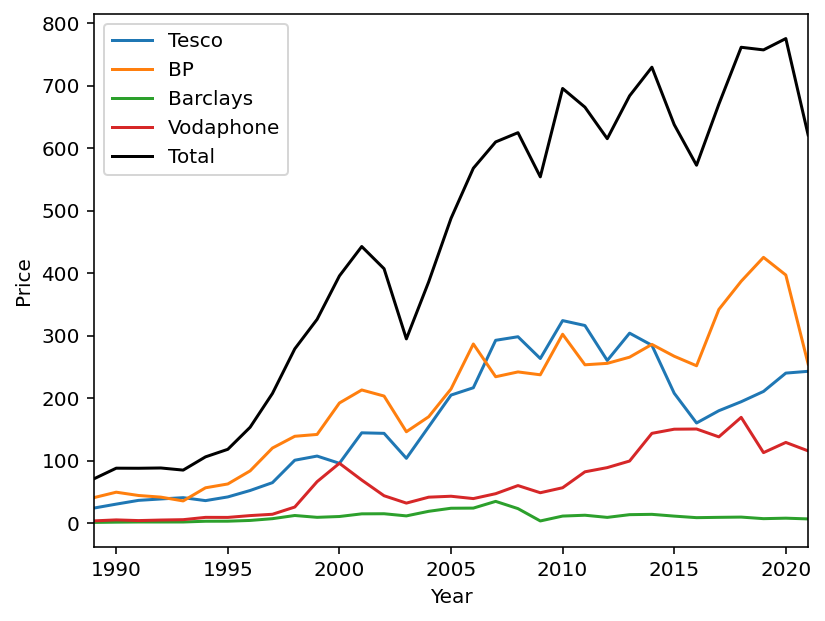

In [8]:
plot_prices_series(df_prices)

In [9]:
df_prices.cov()

,Tesco price,BP price,Barclays price,Vodaphone price,Total
Tesco price,9766.380656,8677.650198,443.508580,3022.483101,21910.022536
BP price,8677.650198,12163.170225,345.370058,4699.801428,25885.991910
Barclays price,443.508580,345.370058,59.293199,69.118230,917.290068
Vodaphone price,3022.483101,4699.801428,69.118230,2627.661654,10419.064413
Total,21910.022536,25885.991910,917.290068,10419.064413,59132.368926


In [10]:
df_prices.corr()

,Tesco price,BP price,Barclays price,Vodaphone price,Total
Tesco price,1.000000,0.796181,0.582818,0.596640,0.911724
BP price,0.796181,1.000000,0.406686,0.831326,0.965225
Barclays price,0.582818,0.406686,1.000000,0.175108,0.489882
Vodaphone price,0.596640,0.831326,0.175108,1.000000,0.835856
Total,0.911724,0.965225,0.489882,0.835856,1.000000


In [11]:
df_prices.corr(method='kendall')

,Tesco price,BP price,Barclays price,Vodaphone price,Total
Tesco price,1.000000,0.643939,0.454545,0.503788,0.715909
BP price,0.643939,1.000000,0.340909,0.708333,0.890152
Barclays price,0.454545,0.340909,1.000000,0.261364,0.367424
Vodaphone price,0.503788,0.708333,0.261364,1.000000,0.727273
Total,0.715909,0.890152,0.367424,0.727273,1.000000


In [12]:
df_prices.describe()

,Tesco price,BP price,Barclays price,Vodaphone price,Total
count,33.000000,33.000000,33.000000,33.000000,33.000000
mean,164.413870,201.571405,10.985586,64.510986,441.481846
std,98.825000,110.286764,7.700208,51.260722,243.171480
min,24.494144,35.913830,1.571551,4.003933,71.249857
25%,65.155853,120.503860,4.718605,14.598728,207.804806
50%,160.541336,214.922073,9.691092,49.015934,487.707494
75%,243.157288,265.760223,13.961011,99.705025,637.596990
max,324.262756,425.389618,35.202843,169.534927,775.208532


### Question 1: UK Cities Data Analysis
We will start by loading the dataset `UK_cities.txt` using whitespace as the separator and explore its basic statistics.

In [13]:
df_cities = pd.read_csv('UK_cities.txt', sep='\\s+', index_col='City')
display(df_cities.head())

,Alternative name,Year granted,Cathedral (pre-1888),City council,Nation/Region,Population
City,,,,,,
Aberdeen,Aiberdeen,1891,High Kirk of Aberdeen (St Machar's),Local government district,Scotland,189120
Armagh,Ard Mhacha,1994,*not applicable*,Local government district,Northern Ireland,59340
Bangor,Bangor,927,Church of St Deiniol,Community,Wales,16358
Bath,Aquae Sulis,1090,Abbey Church of SS Peter & Paul,Charter trustees,England,88859
Belfast,Beal Feirste,1888,*not applicable*,Local government district,Northern Ireland,333871


In [14]:
def plot_region_pie(dfgrp_region):
    """
    Plots sum of regional cities
    """
    plt.figure(figsize=(8, 8), dpi=144)

    # Plotting using the provided grouped data
    dfgrp_region.plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=140,
        colormap='viridis',
        textprops={'fontsize': 10}
    )

    plt.title('UK Population Share by Nation/Region', fontsize=12, weight='bold')
    plt.ylabel('')  # Clear the y-axis label for layout purposes
    plt.tight_layout()
    plt.show()
    return

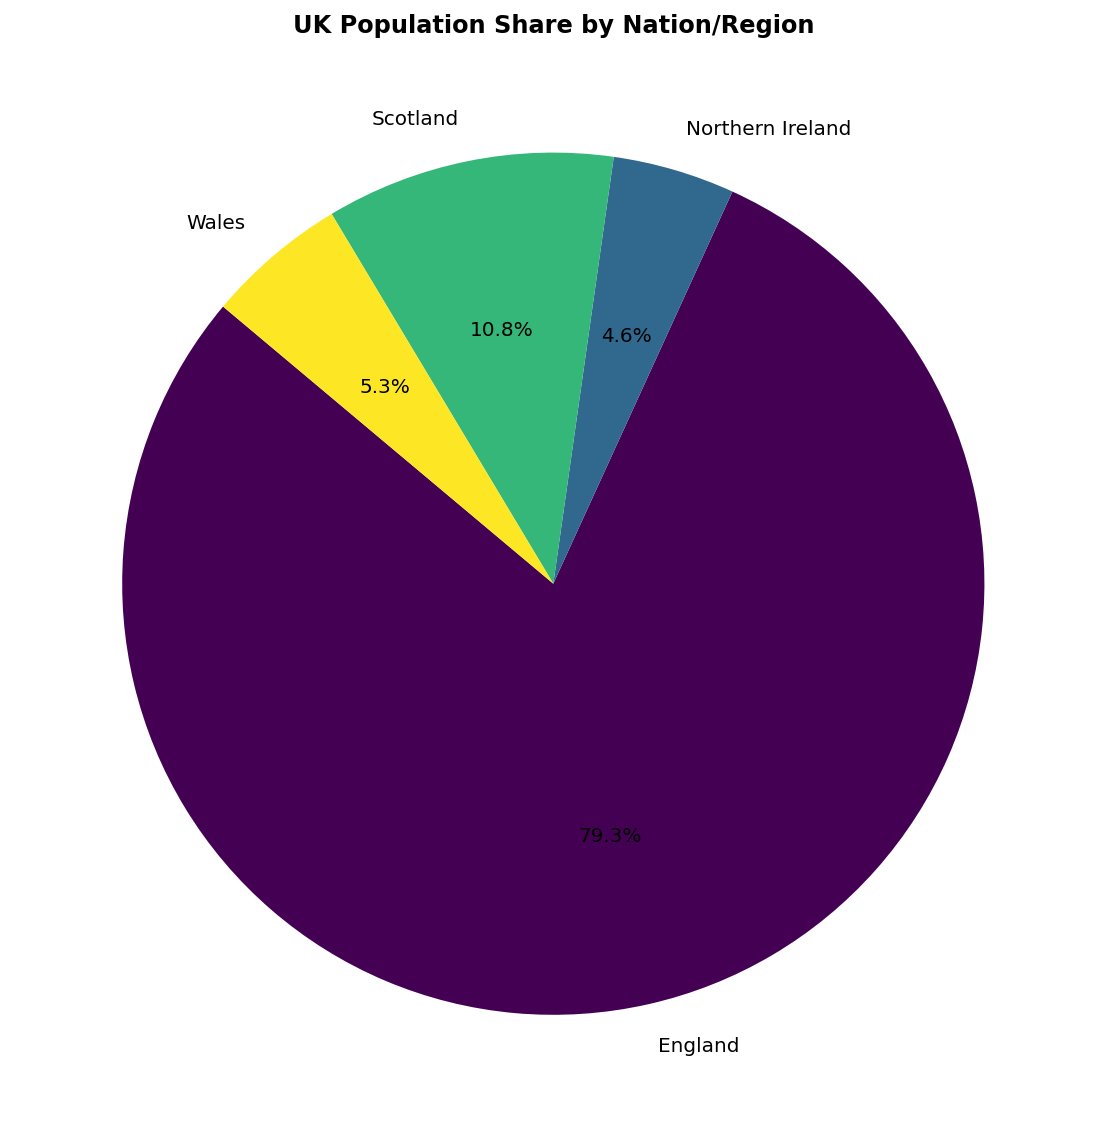

In [17]:
dfgrp_region = df_cities.groupby('Nation/Region')['Population'].sum()
plot_region_pie(dfgrp_region)

In [18]:
sample1 = np.random.normal(1.0, 1.0, 10000)
sample2 = np.random.normal(3.0, 2.0, 10000)

In [19]:
def plot_sample_box(*samples):
    """
    Creates box plot of random samples
    """
    plt.figure(dpi=144)

    plt.boxplot(samples, labels=[f'Sample {i+1}' for i in range(len(samples))])

    plt.ylabel('Range')
    plt.show()
    return

/tmp/ipykernel_2471/329170679.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(samples, labels=[f'Sample {i+1}' for i in range(len(samples))])


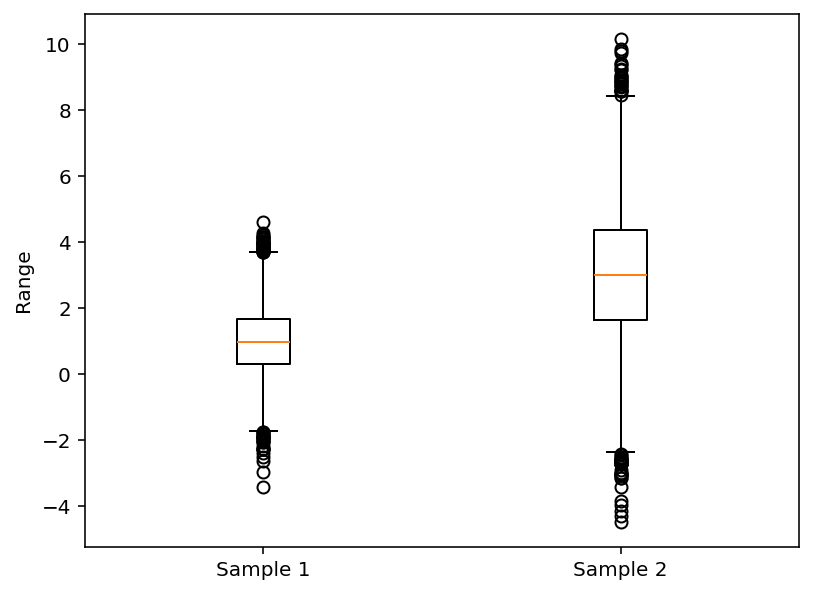

In [20]:
plot_sample_box(sample1, sample2)

In [21]:
def plot_sample_violin(*samples):
    """
    Creates violin plot of random samples
    """
    plt.figure(dpi=144)

    plt.violinplot(samples)

    plt.xticks(np.arange(1, len(samples) + 1), labels=[f'Sample {i+1}' for i in range(len(samples))])
    plt.ylabel('Range')
    plt.show()
    return

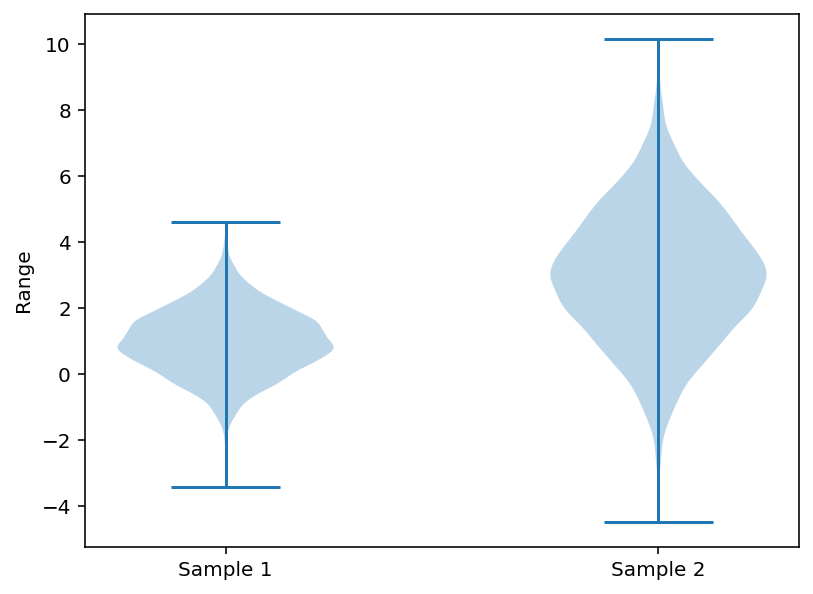

In [22]:
plot_sample_violin(sample1, sample2)

Violin plots show all of the data (this can be customised) but also shows a more meaningful representation of where the data points lie.

# Question 2
## Create a boxplot and violin plot for the annual returns of the previous financial data (Tesco, BP, Barclays, Vodaphone).

In [23]:
df_returns = df[[col for col in df.columns if 'ann_return' in col]].copy()
df_returns.head()

,Tesco ann_return,BP ann_return,Barclays ann_return,Vodaphone ann_return
year,,,,
1989,22.941372,19.174906,25.596115,33.478386
1990,17.814613,-11.157063,12.323343,-21.962895
1991,5.895034,-6.082900,-0.793578,17.645562
1992,5.149691,-15.618524,1.578620,10.330250
1993,-12.174125,46.029975,53.486592,48.265578


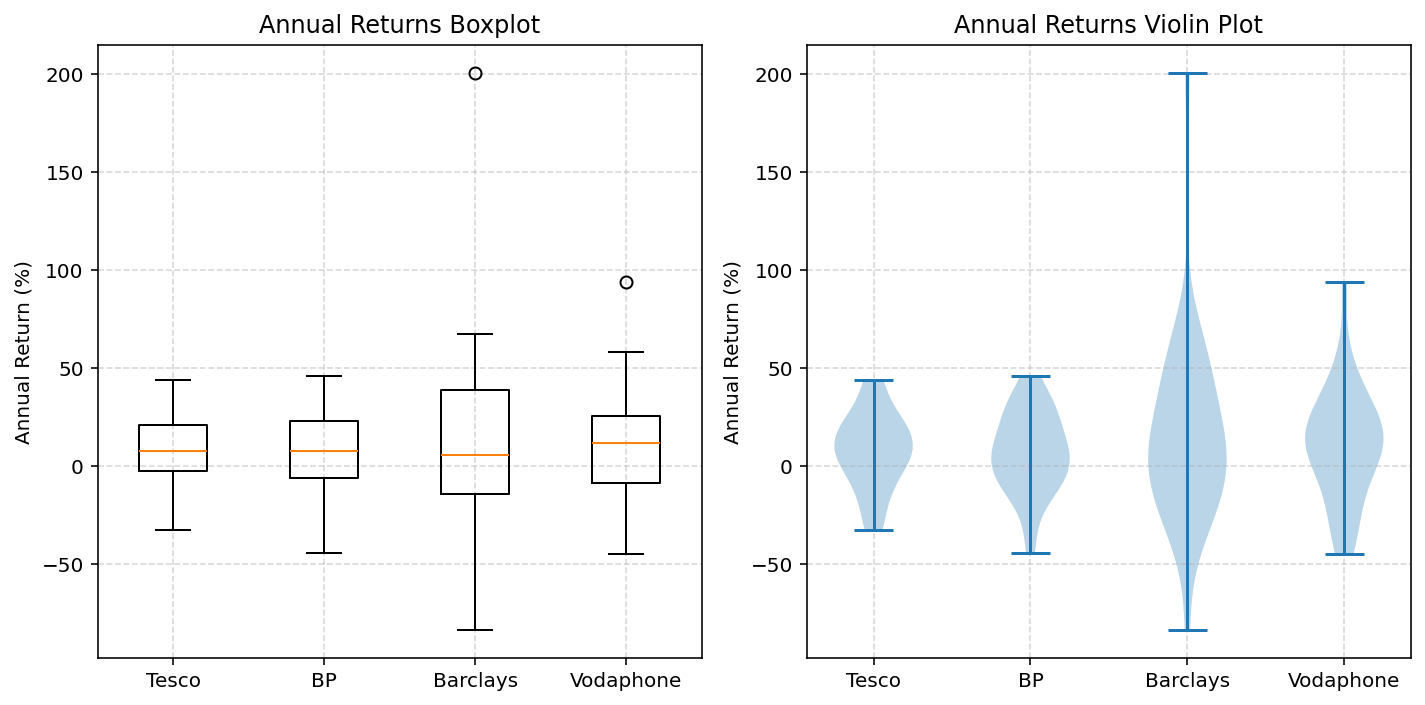

In [24]:
plt.figure(figsize=(10, 5), dpi=144)

# Box Plot
plt.subplot(1, 2, 1)
plt.boxplot([df_returns[col].dropna() for col in df_returns.columns], tick_labels=companies)
plt.title('Annual Returns Boxplot')
plt.ylabel('Annual Return (%)')
plt.grid(True, linestyle='--', alpha=0.5)

# Violin Plot
plt.subplot(1, 2, 2)
plt.violinplot([df_returns[col].dropna() for col in df_returns.columns])
plt.xticks(np.arange(1, len(companies) + 1), labels=companies)
plt.title('Annual Returns Violin Plot')
plt.ylabel('Annual Return (%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [28]:
def plot_price_correlation(df_prices, method):
    """
    Plots correlation of prices with different methods
    """
    fig, ax = plt.subplots(dpi=144)

    mask = np.triu(np.ones_like(df_prices.corr()))
    sns.heatmap(df_prices.corr(method=method), ax=ax, vmin=-1, vmax=1, cmap='RdBu', annot=True, mask=mask)
    plt.title(method.capitalize())
    plt.show()
    return

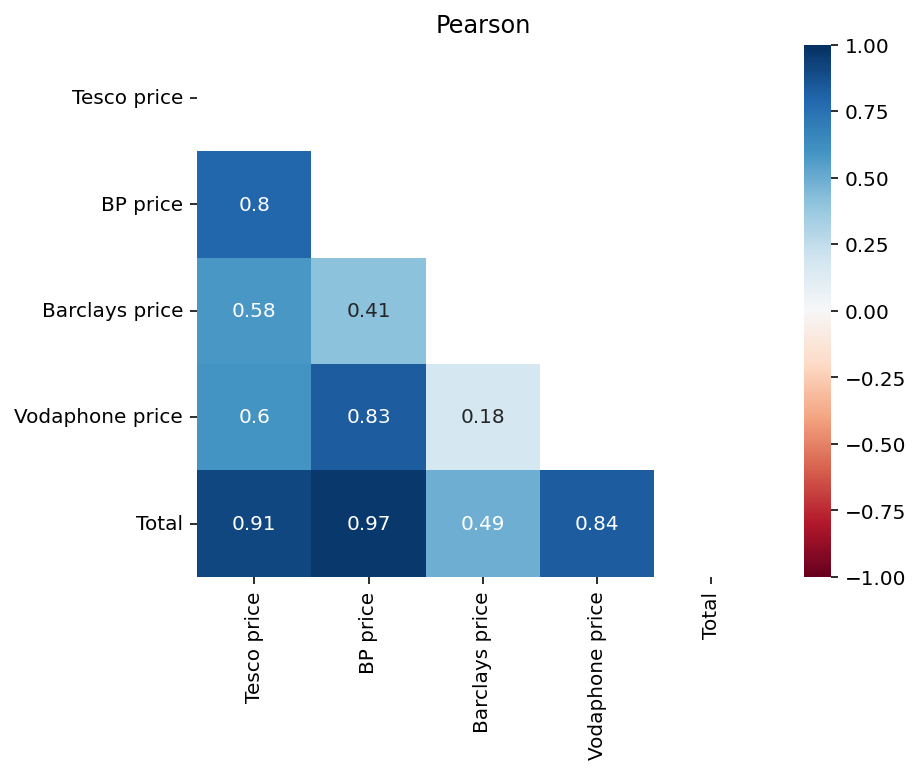

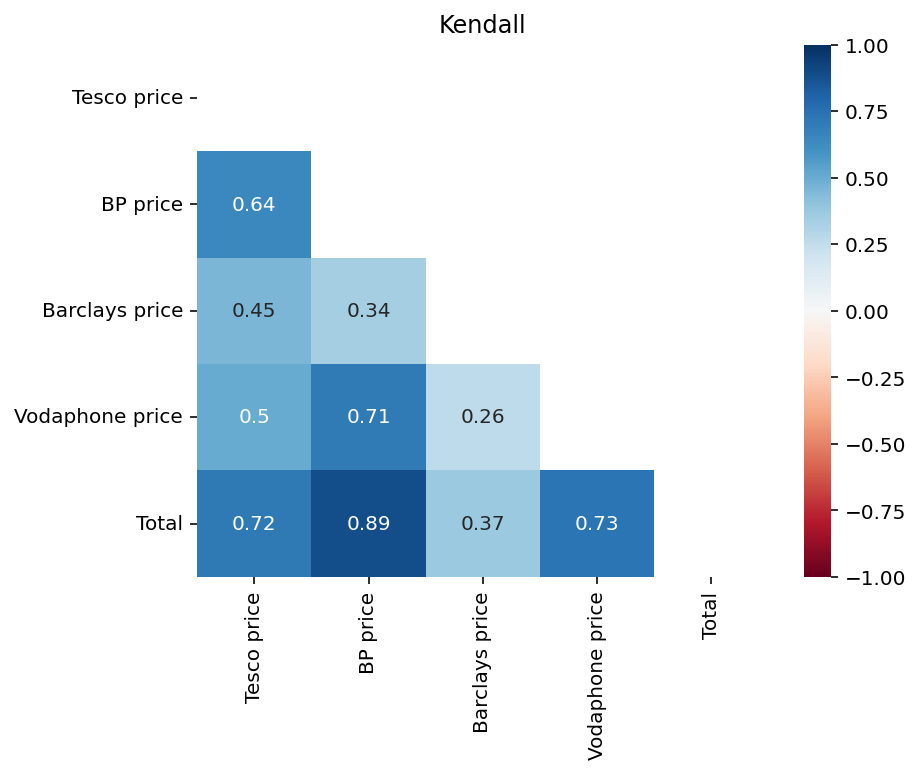

In [29]:
plot_price_correlation(df_prices, 'pearson')
plot_price_correlation(df_prices, 'kendall')

# Question 3
Create both types of correlations as heatmaps for the annual returns financial data (including a total), grouped by decade, between 1990 and 2019.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the returns data with a Total column
df_returns_q3 = df_returns.copy()
df_returns_q3['Total'] = df_returns_q3.sum(axis=1)

# Filter for years between 1990 and 2019
df_returns_cut = df_returns_q3.loc[1990:2019].copy()

# Create a decade grouping column
df_returns_cut['decade'] = (df_returns_cut.index // 10) * 10
dfgrp_returns_decade = df_returns_cut.groupby('decade')

In [31]:
def plot_returns_correlation(dfgrp_returns, method, decade_name):
    """
    Plots correlation of returns with different methods
    """
    # Exclude the grouping column 'decade'
    df_corr_data = dfgrp_returns.drop(columns=['decade'], errors='ignore')

    fig, ax = plt.subplots(figsize=(6, 4), dpi=144)
    corr_matrix = df_corr_data.corr(method=method)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix,
        ax=ax,
        vmin=-1,
        vmax=1,
        cmap='RdBu',
        annot=True,
        mask=mask
    )
    plt.title(f"{method.capitalize()} Correlation - {decade_name}s")
    plt.tight_layout()
    plt.show()

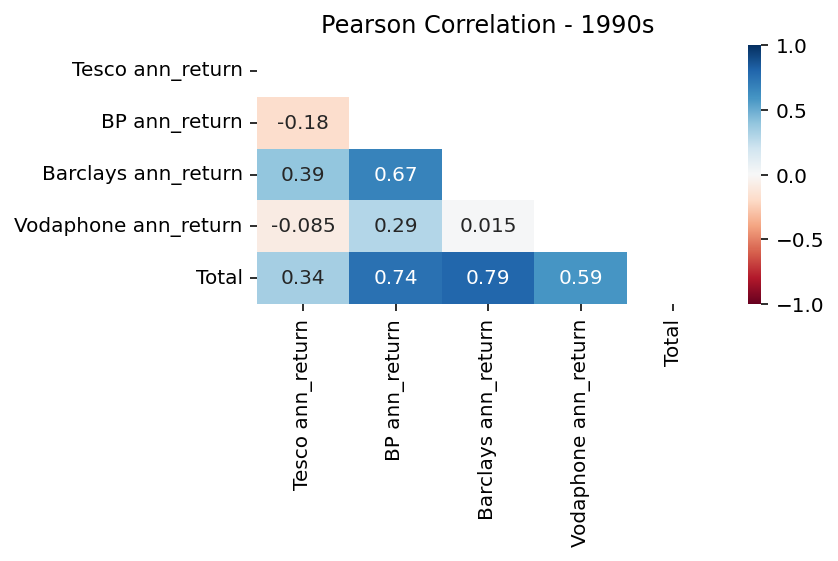

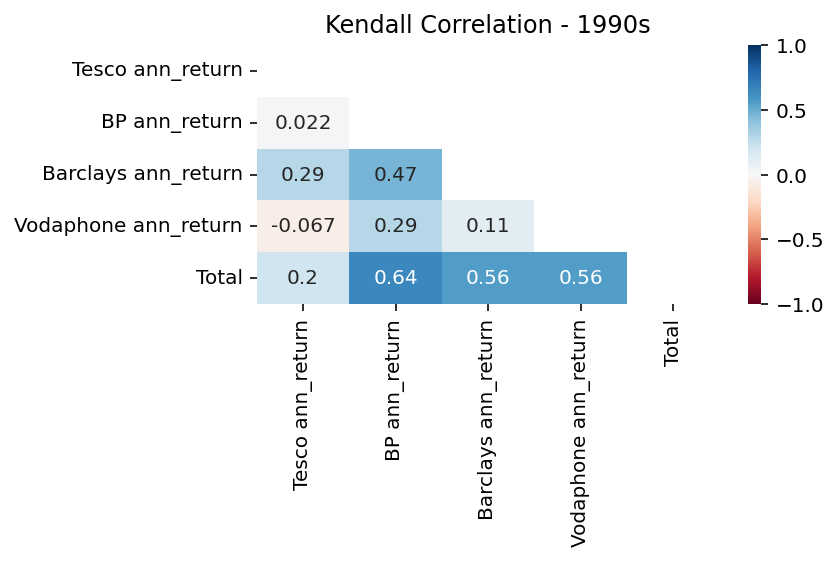

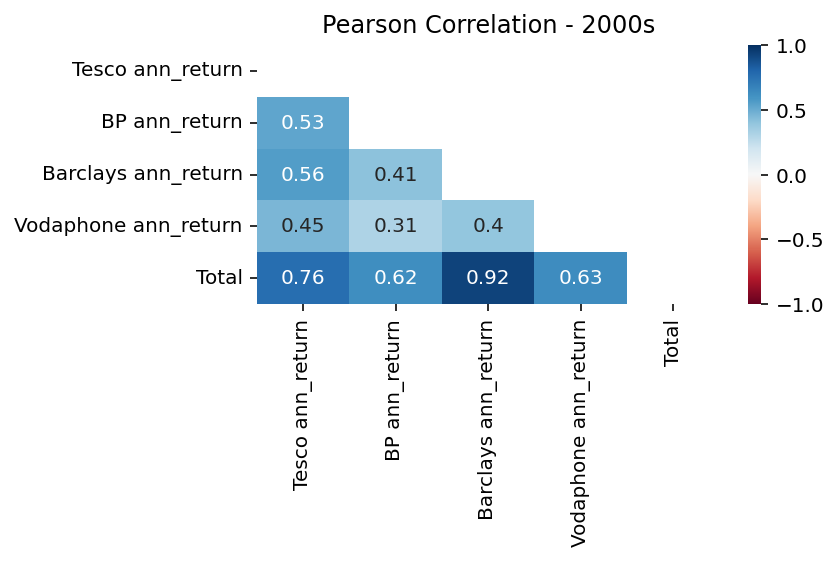

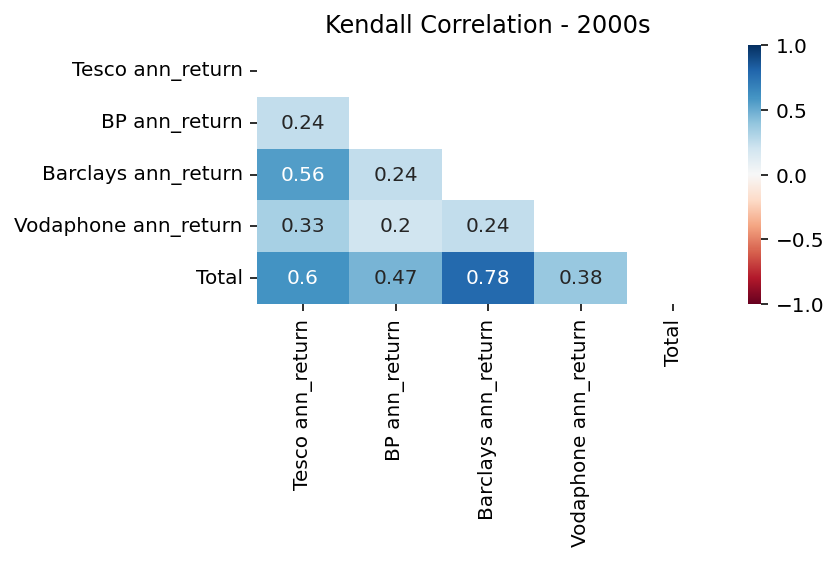

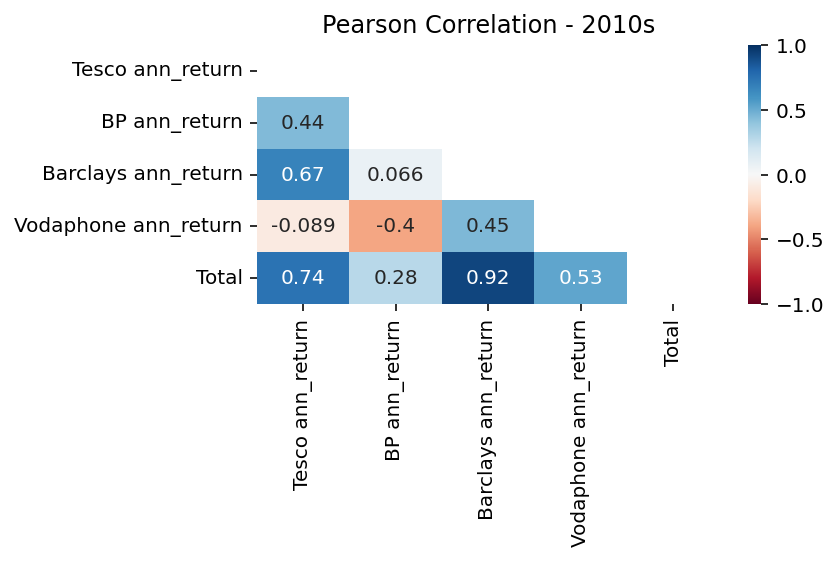

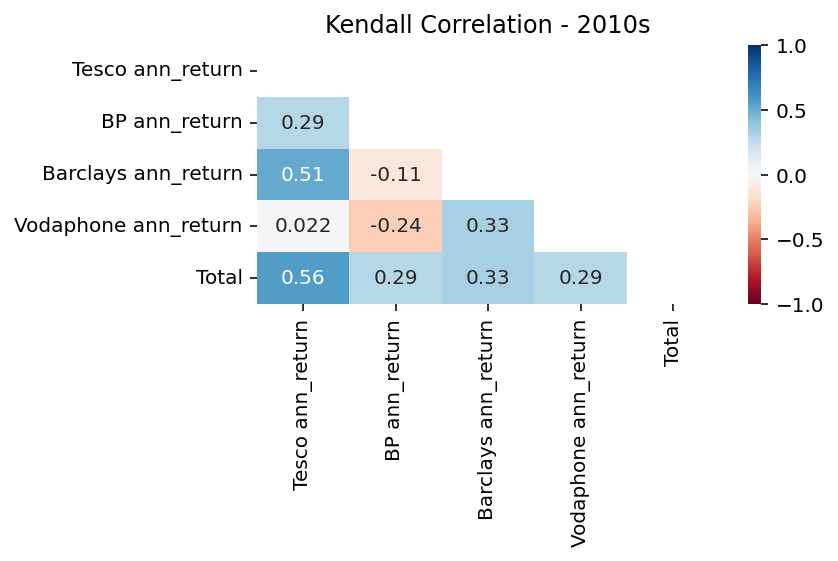

In [32]:
for decade, group in dfgrp_returns_decade:
    plot_returns_correlation(group, 'pearson', str(decade))
    plot_returns_correlation(group, 'kendall', str(decade))